In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("mississauga_planning_mockdata_FINAL_v1.csv")

# Clean column names (just in case)
df.columns = df.columns.str.strip()

# Ensure key numeric columns are numeric
num_cols = [
    "approval_score",
    "displacement_risk_score",
    "property_value_change_pct",
    "traffic_delta_pct",
    "environmental_stress_change",
    "shadow_impact_score",
    "transit_rider_impact",
    "construction_loan_feasibility",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Ensure decision column is numeric 0/1
df["synthetic_approval"] = pd.to_numeric(df["synthetic_approval"], errors="coerce")

df.head()

,application_id,submission_date,application_status,district_id,proposed_use,max_storeys,residential_units,non_residential_gfa_m2,inside_mtsa,mtsa_corridor,...,estimated_new_riders_daily,property_value_change_pct,default_risk_score,capital_concentration_risk,construction_loan_feasibility,insurance_premium_shift_index,rent_increase_forecast_pct,rent_burden_score,displacement_risk_score,transit_speed_impact_score
0,SPM 22 107,2022-07-29,Withheld,1.0,General Retail Commercial,2.0,0,158.38,1,Dundas BRT,...,0,5.7,3,0,100,0,6.2,52,37,100
1,SP 22 10,2022-01-19,Withheld,5.0,General Retail Commercial,6.0,0,10175.00,0,Not within a Major Transit Station Area.,...,0,4.2,15,5,39,7,6.1,53,39,91
2,SP 22 103,2022-07-20,Withheld,1.0,Residential Townhouses,3.0,70,0.00,0,Not within a Major Transit Station Area.,...,41,4.8,18,1,40,5,6.8,59,47,88
3,SP 23 2,2023-01-17,Withheld,9.0,Residential Townhouses; Residential Apartments,12.0,212,0.00,0,Not within a Major Transit Station Area.,...,131,8.8,8,4,37,7,8.4,68,63,96
4,OZ/OPA 22 5,2022-01-31,Appealed,1.0,Residential Apartments; General Retail Commercial,NaN,42,150.00,1,Hurontario LRT,...,23,4.6,3,1,98,2,5.4,45,27,100


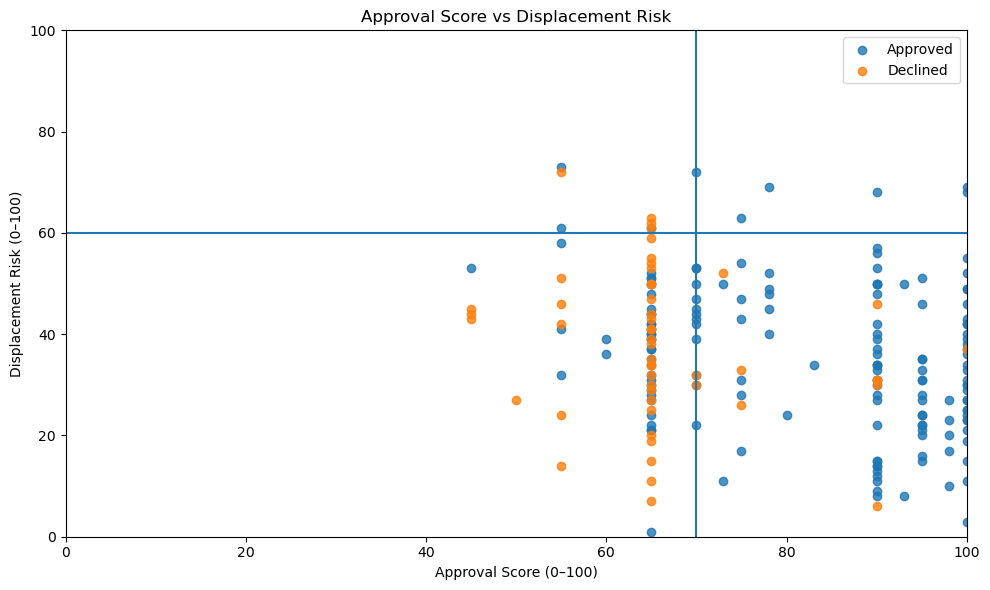

In [2]:
THRESH_APPROVAL = 70
THRESH_DISPLACE = 60

approved = df[df["synthetic_approval"] == 1]
declined = df[df["synthetic_approval"] == 0]

plt.figure(figsize=(10,6))
plt.scatter(approved["approval_score"], approved["displacement_risk_score"], label="Approved", alpha=0.8)
plt.scatter(declined["approval_score"], declined["displacement_risk_score"], label="Declined", alpha=0.8)

plt.axvline(THRESH_APPROVAL)
plt.axhline(THRESH_DISPLACE)

plt.title("Approval Score vs Displacement Risk")
plt.xlabel("Approval Score (0–100)")
plt.ylabel("Displacement Risk (0–100)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig("visual_1_approval_vs_displacement.png", dpi=200)
plt.show()

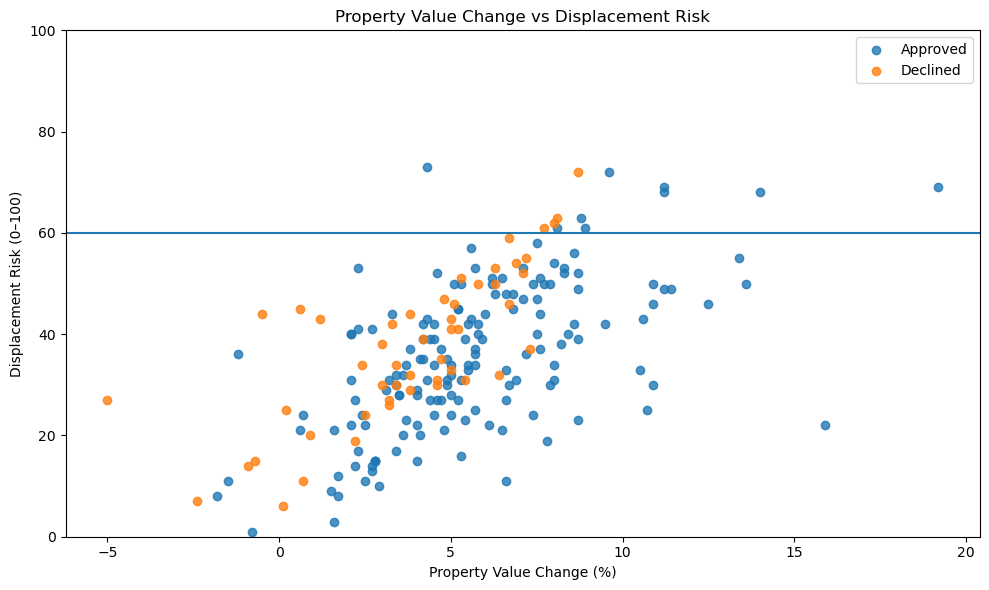

In [3]:
plt.figure(figsize=(10,6))
plt.scatter(approved["property_value_change_pct"], approved["displacement_risk_score"], label="Approved", alpha=0.8)
plt.scatter(declined["property_value_change_pct"], declined["displacement_risk_score"], label="Declined", alpha=0.8)

plt.axhline(THRESH_DISPLACE)

plt.title("Property Value Change vs Displacement Risk")
plt.xlabel("Property Value Change (%)")
plt.ylabel("Displacement Risk (0–100)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig("visual_2_value_vs_displacement.png", dpi=200)
plt.show()

Approval Breakdown by Risk Level

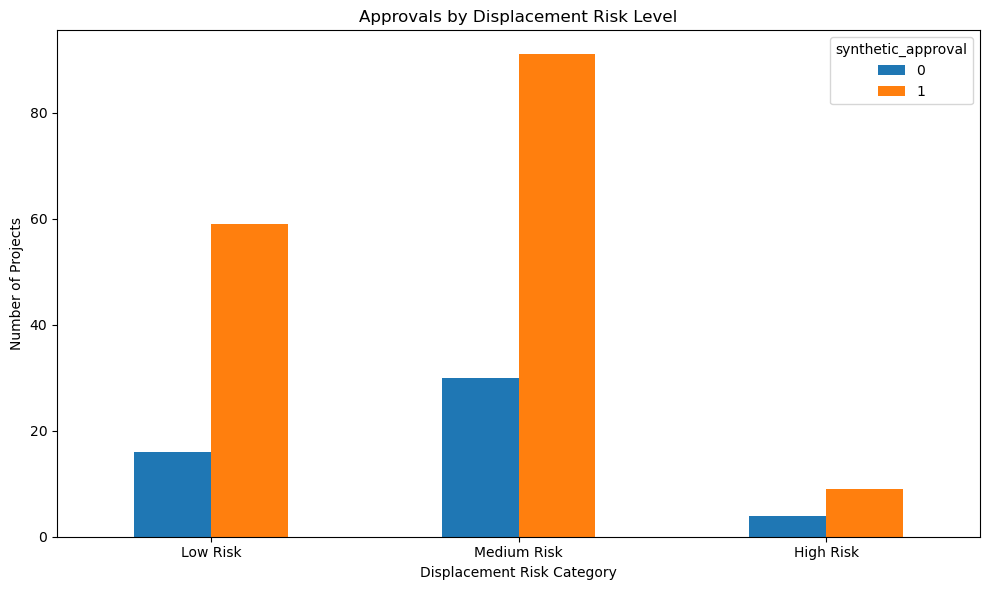

In [7]:
# Create risk category
bins = [0, 30, 60, 100]
labels = ["Low Risk", "Medium Risk", "High Risk"]

df["risk_category"] = pd.cut(df["displacement_risk_score"], bins=bins, labels=labels, include_lowest=True)

# Create summary table
summary = pd.crosstab(df["risk_category"], df["synthetic_approval"])

summary.plot(kind="bar", figsize=(10,6))
plt.title("Approvals by Displacement Risk Level")
plt.xlabel("Displacement Risk Category")
plt.ylabel("Number of Projects")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

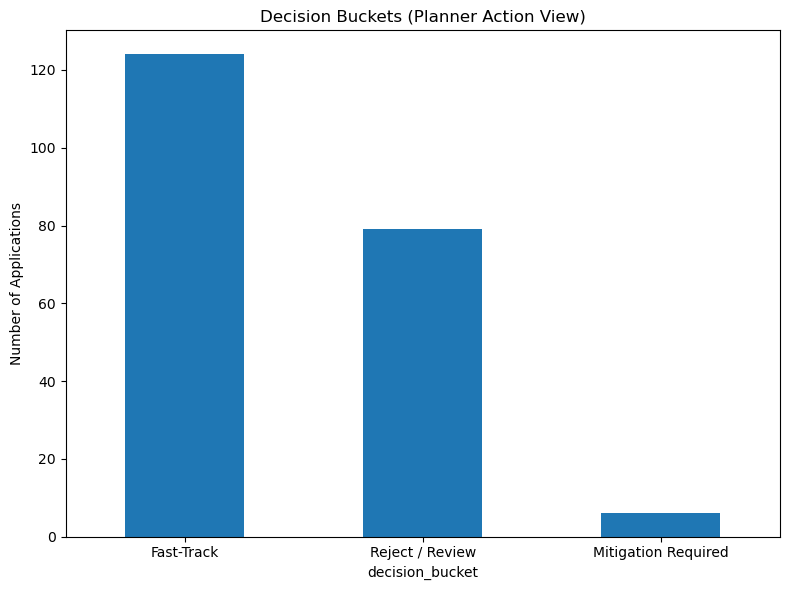

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("mississauga_planning_mockdata_FINAL_v1.csv")
df.columns = df.columns.str.strip()

df["approval_score"] = pd.to_numeric(df["approval_score"], errors="coerce")
df["displacement_risk_score"] = pd.to_numeric(df["displacement_risk_score"], errors="coerce")

conditions = [
    (df["approval_score"] >= 70) & (df["displacement_risk_score"] <= 60),
    (df["approval_score"] >= 70) & (df["displacement_risk_score"] > 60),
    (df["approval_score"] < 70),
]
choices = ["Fast-Track", "Mitigation Required", "Reject / Review"]
df["decision_bucket"] = np.select(conditions, choices)

bucket_counts = df["decision_bucket"].value_counts()

plt.figure(figsize=(8,6))
bucket_counts.plot(kind="bar")
plt.title("Decision Buckets (Planner Action View)")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

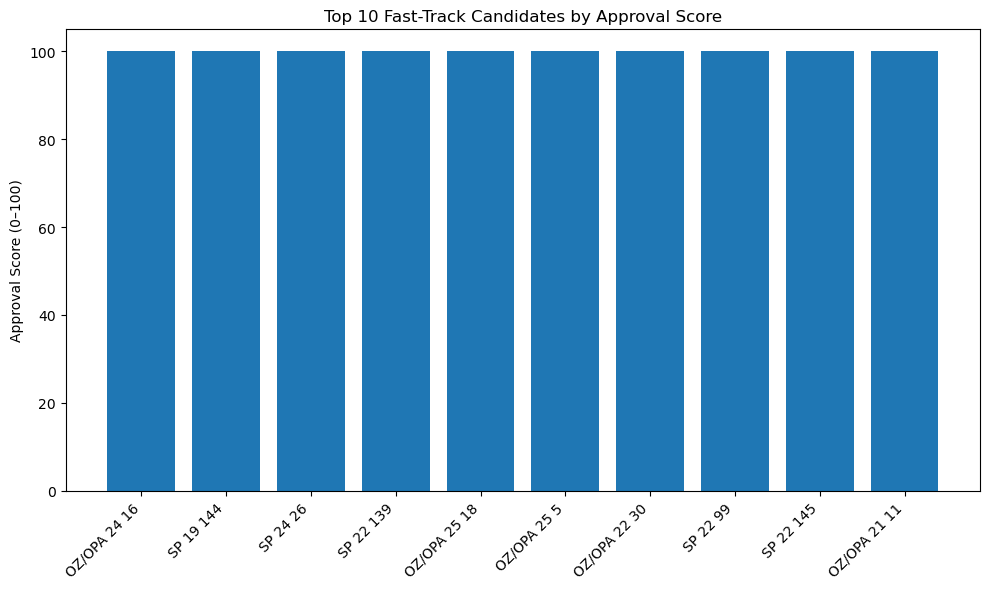

In [21]:
plt.figure(figsize=(10,6))
plt.bar(top10["application_id"].astype(str), top10["approval_score"])
plt.title("Top 10 Fast-Track Candidates by Approval Score")
plt.ylabel("Approval Score (0–100)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("mississauga_planning_mockdata_FINAL_v1.csv")
df.columns = df.columns.str.strip()

# Ensure numeric
df["approval_score"] = pd.to_numeric(df["approval_score"], errors="coerce")
df["synthetic_approval"] = pd.to_numeric(df["synthetic_approval"], errors="coerce")

df["displacement_risk_score"] = pd.to_numeric(df.get("displacement_risk_score"), errors="coerce")
df["transit_rider_impact"] = pd.to_numeric(df.get("transit_rider_impact"), errors="coerce")

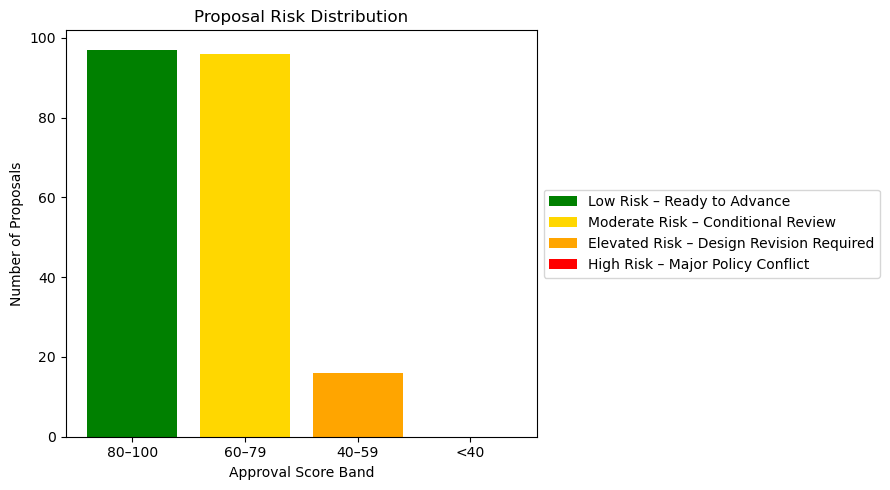

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Reclassify into score bands only
def classify(score):
    if score >= 80:
        return "80–100"
    elif score >= 60:
        return "60–79"
    elif score >= 40:
        return "40–59"
    else:
        return "<40"

df["approval_band"] = df["approval_score"].apply(classify)

counts = (
    df["approval_band"]
    .value_counts()
    .reindex(["80–100", "60–79", "40–59", "<40"], fill_value=0)
)

plt.figure(figsize=(9,5))

colors = ["green", "gold", "orange", "red"]

plt.bar(counts.index, counts.values, color=colors)

plt.title("Proposal Risk Distribution")
plt.ylabel("Number of Proposals")
plt.xlabel("Approval Score Band")

# Executive legend
legend_elements = [
    Patch(facecolor="green", label="Low Risk – Ready to Advance"),
    Patch(facecolor="gold", label="Moderate Risk – Conditional Review"),
    Patch(facecolor="orange", label="Elevated Risk – Design Revision Required"),
    Patch(facecolor="red", label="High Risk – Major Policy Conflict")
]

plt.legend(handles=legend_elements, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

This bar chart illustrates the distribution of simulated development proposals across predefined approval score bands, translating quantitative scores into actionable risk categories. Each proposal receives a composite approval score (0–100) derived from Urban, Financial, and Socioeconomic factors, and is then grouped into one of four decision-support bands: 80–100 (Low Risk – Ready to Advance), 60–79 (Moderate Risk – Conditional Review), 40–59 (Elevated Risk – Design Revision Required), and Below 40 (High Risk – Major Policy Conflict). The distribution shows that the majority of proposals fall within the Low and Moderate risk categories, indicating general alignment with policy and infrastructure thresholds, while a smaller subset requires revision before proceeding. Importantly, these bands are not model predictions but deterministic classification thresholds applied to the composite score. The purpose of this visualization is to help planners quickly understand the overall portfolio risk profile, prioritize review resources, and identify how many proposals may require mitigation, redesign, or deeper policy evaluation before advancing through the approval process.

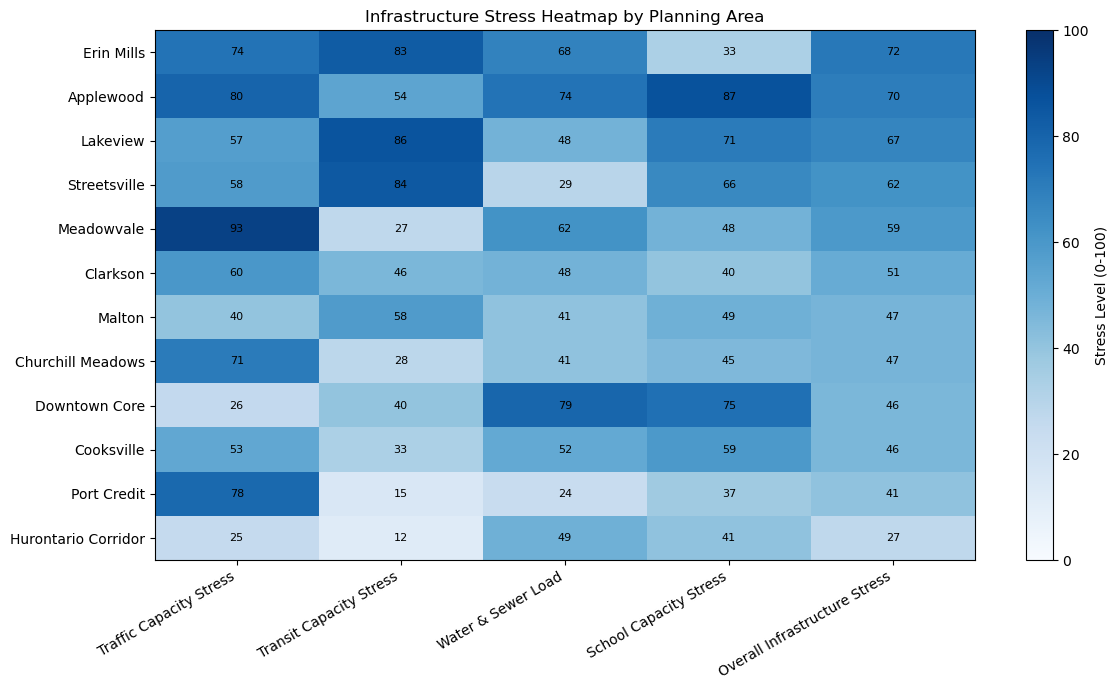

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Create mock infrastructure stress data
# -----------------------------
np.random.seed(7)

area_names = [
    "Downtown Core",
    "Port Credit",
    "Cooksville",
    "Erin Mills",
    "Meadowvale",
    "Clarkson",
    "Streetsville",
    "Hurontario Corridor",
    "Malton",
    "Lakeview",
    "Churchill Meadows",
    "Applewood"
]

n = len(area_names)

df = pd.DataFrame({
    "Planning Area": area_names,
    "Traffic Capacity Stress": np.random.uniform(20, 95, n),
    "Transit Capacity Stress": np.random.uniform(10, 90, n),
    "Water & Sewer Load": np.random.uniform(15, 85, n),
    "School Capacity Stress": np.random.uniform(10, 95, n),
})

# -----------------------------
# 2) Composite Infrastructure Stress Score
# -----------------------------
weights = {
    "Traffic Capacity Stress": 0.35,
    "Transit Capacity Stress": 0.35,
    "Water & Sewer Load": 0.20,
    "School Capacity Stress": 0.10
}

df["Overall Infrastructure Stress"] = (
    weights["Traffic Capacity Stress"] * df["Traffic Capacity Stress"]
    + weights["Transit Capacity Stress"] * df["Transit Capacity Stress"]
    + weights["Water & Sewer Load"] * df["Water & Sewer Load"]
    + weights["School Capacity Stress"] * df["School Capacity Stress"]
)

# -----------------------------
# 3) Prepare Heatmap
# -----------------------------
heat = (
    df.set_index("Planning Area")
      .round(0)
      .sort_values("Overall Infrastructure Stress", ascending=False)
)

# -----------------------------
# 4) Plot Heatmap
# -----------------------------
plt.figure(figsize=(12, 7))

im = plt.imshow(
    heat.values,
    aspect="auto",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.xticks(range(len(heat.columns)), heat.columns, rotation=30, ha="right")
plt.yticks(range(len(heat.index)), heat.index)

cbar = plt.colorbar(im)
cbar.set_label("Stress Level (0-100)")

plt.title("Infrastructure Stress Heatmap by Planning Area")

# Add values in each cell
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = int(heat.iloc[i, j])
        plt.text(j, i, value, ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

This heatmap presents simulated infrastructure stress levels (scaled 0–100) across major planning areas in Mississauga, broken down by Traffic Capacity, Transit Capacity, Water & Sewer Load, School Capacity, and a composite Overall Infrastructure Stress score. Darker shades indicate higher system pressure, allowing for quick identification of constraint zones. For example, Meadowvale shows very high traffic stress (93), Lakeview and Streetsville exhibit elevated transit strain (86 and 84), and Applewood demonstrates high school capacity pressure (87). The Downtown Core also shows significant water and sewer load (79), suggesting potential servicing limitations for additional density. The overall stress column aggregates these components to provide a structured, high-level feasibility indicator while preserving transparency at the infrastructure level. This visualization is not predictive; rather, it functions as a decision-support tool to help planners assess where new development proposals may require mitigation measures, phased approvals, or infrastructure investment before intensification can proceed.